1. Preparación y organización de los datos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

usuarios = pd.read_csv("dataset/usuarios_win_mac_lin.csv")

usuarios.head()

,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


In [2]:
usuarios.info()

<class 'pandas.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duracion  170 non-null    float64
 1   paginas   170 non-null    int64  
 2   acciones  170 non-null    int64  
 3   valor     170 non-null    int64  
 4   clase     170 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 6.8 KB


In [3]:
usuarios.describe()

,duracion,paginas,acciones,valor,clase
count,170.000000,170.000000,170.000000,170.000000,170.000000
mean,111.075729,2.041176,8.723529,32.676471,0.752941
std,202.453200,1.500911,9.136054,44.751993,0.841327
min,1.000000,1.000000,1.000000,1.000000,0.000000
25%,11.000000,1.000000,3.000000,8.000000,0.000000
50%,13.000000,2.000000,6.000000,20.000000,0.000000
75%,108.000000,2.000000,10.000000,36.000000,2.000000
max,898.000000,9.000000,63.000000,378.000000,2.000000


2. Exploración de los datos

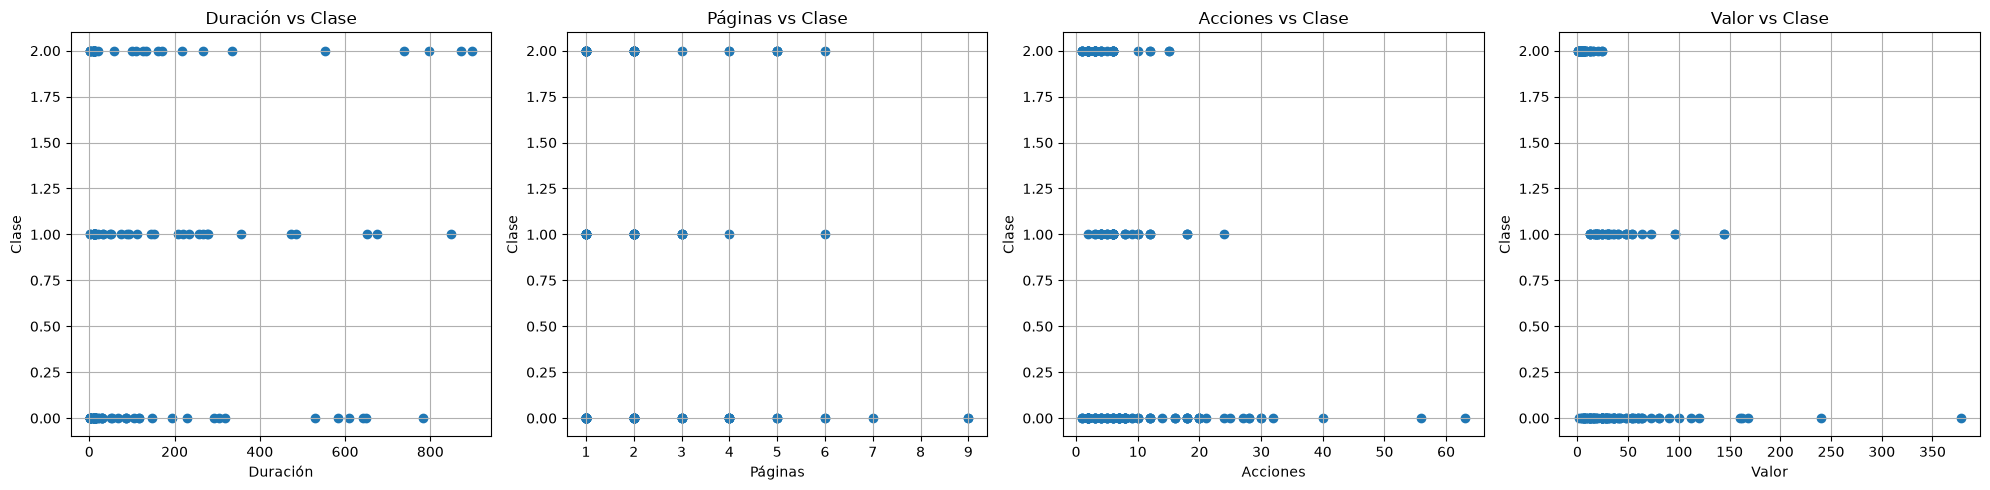

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].scatter(usuarios["duracion"], usuarios["clase"])
axes[0].set_xlabel("Duración")
axes[0].set_ylabel("Clase")
axes[0].set_title("Duración vs Clase")
axes[0].grid()

axes[1].scatter(usuarios["paginas"], usuarios["clase"])
axes[1].set_xlabel("Páginas")
axes[1].set_ylabel("Clase")
axes[1].set_title("Páginas vs Clase")
axes[1].grid()

axes[2].scatter(usuarios["acciones"], usuarios["clase"])
axes[2].set_xlabel("Acciones")
axes[2].set_ylabel("Clase")
axes[2].set_title("Acciones vs Clase")
axes[2].grid()

axes[3].scatter(usuarios["valor"], usuarios["clase"])
axes[3].set_xlabel("Valor")
axes[3].set_ylabel("Clase")
axes[3].set_title("Valor vs Clase")
axes[3].grid()

plt.tight_layout()
plt.show()

3. Modelado de los datos

In [5]:
X = usuarios[["duracion", "paginas", "acciones", "valor"]]
y = usuarios["clase"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [6]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(
    max_iter=1000,
    solver="lbfgs"
)

modelo.fit(X_train, y_train);

In [7]:
y_pred = modelo.predict(X_test)

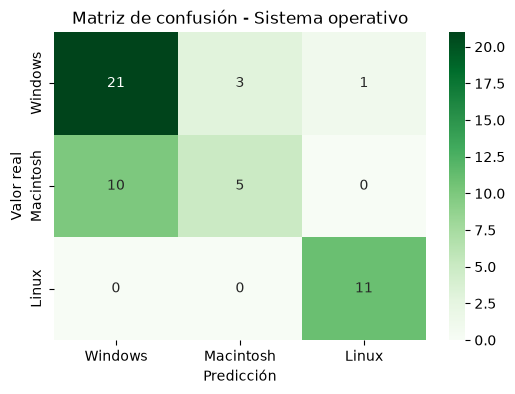

In [8]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Windows", "Macintosh", "Linux"],
    yticklabels=["Windows", "Macintosh", "Linux"]
)

plt.title("Matriz de confusión - Sistema operativo")
plt.ylabel("Valor real")
plt.xlabel("Predicción")
plt.show()

In [9]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Windows", "Macintosh", "Linux"]
))

              precision    recall  f1-score   support

     Windows       0.68      0.84      0.75        25
   Macintosh       0.62      0.33      0.43        15
       Linux       0.92      1.00      0.96        11

    accuracy                           0.73        51
   macro avg       0.74      0.72      0.71        51
weighted avg       0.71      0.73      0.70        51

